# The rebrand tell — is a new logo a comeback, or a cry for help? 🎨
### The company that changes its name or logo — renewal, or a floundering firm's vanity — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Renewal or red--flag%3F: Coin_flip](https://img.shields.io/badge/Renewal_or_red--flag%3F-Coin_flip-8b949e?style=flat-square)

Two camps swear opposite things about the same event. **Camp Renewal:** when a company unveils a fresh name or logo — Google → *Alphabet*, Facebook → *Meta* — it's announcing a turnaround; the stock re-rates, so **buy the rebrand**. **Camp Red-Flag:** a rebrand is what a *struggling* firm does to distract from a rotting business — a vanity move, a **sell signal**. Both can't be right, and a rebrand is a public, dated event — so we can just look.

This notebook builds a transparent table of **~26 real corporate rebrands (2010–2025)** — name changes, identity refreshes, and pure logo redesigns — and asks what actually happened to the stock: a quick pop the week of the reveal, and the six months after.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo test and the power analysis? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** Some of the loudest rebrands **left the market**: *Twitter → X* went private, *Weight Watchers → WW* filed for bankruptcy in 2025, *Paramount* got swallowed in 2025. The names we *can* still price are the ones that *survived* — which biases everything **against** the 'floundering firm' story, and makes it all the more telling what the survivors show. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from logo_rebrand import data, strategy as st

HAVE_REAL = data.have_real()
B = data.load_real() if HAVE_REAL else None
EV = st.collect_events(B) if HAVE_REAL else None
print("real rebrand-tape cache present:", HAVE_REAL,
      "| events priced:", (0 if EV is None else len(EV)))

# frozen headline numbers (mirror of docs/results.md)
R = {'n_table': 26, 'n_delisted': 8, 'n_priced': 22, 'asof': '2026-06-30', 'fp': 'c12adbfe3fd2', 'announce': (2.44, 64, 1.96, 0.022), 'drift': (-4.61, 45, -1.05, 0.333), 'announce_median': 1.6, 'kinds': [('name', 8, 3.56, -16.4), ('identity', 5, 0.64, -9.06), ('logo', 9, 2.45, 8.34)], 'fragile': [(0, 22, 2.44, 1.96), (1, 21, 1.71, 1.62), (2, 20, 1.02, 1.21), (3, 19, 0.68, 0.84)], 'robust': [('3/60', 22, 1.74, 1.78, -1.7, -0.51), ('5/120', 22, 2.44, 1.96, -4.61, -1.05), ('5/252', 22, 2.44, 1.96, -9.18, -1.38), ('10/120', 22, 2.27, 1.29, -4.85, -1.32), ('1/120', 22, 0.24, 0.34, -1.82, -0.38)], 'cost': {'gross_hold': -2.17, 'net_hold': -2.37, 'gross_announce': 2.44, 'net_announce': 2.24, 'gross_drift': -4.61, 'net_drift': -4.81}, 'syn': [(0.0, 26, -0.32, -0.31, -0.52, -0.1), (0.3, 26, -0.32, -0.31, 34.28, 5.05)]}


real rebrand-tape cache present: True | events priced: 22


## The answer first

| Question | Answer |
|---|---|
| Does a rebrand pop the stock the week of the reveal? | **A little — but don't bank on it.** The first-week bump averages **+2.4%**, but it's carried by two news-confounded outliers; drop them and it fades to a coin-flip. |
| Does a rebrand mark a *renewal* — outperformance in the months after? | **No.** Over the next ~6 months the survivors drift **-5%**, statistically zero. No turnaround shows up in the price. |
| Is it a *floundering-firm* red flag, then? | **Also no — not on the survivors.** The drift is slightly negative but indistinguishable from noise, and the real disasters already **left the tape**. |
| Can you trade 'buy the rebrand'? | **It loses money.** Buying the reveal and holding is **-2.2% per event before costs** — the soft negative drift eats the little pop. |

> A rebrand is neither a reliable comeback nor a reliable tell. The week-one pop is a fragile whisper; the months after are noise. It's a coin flip wearing a new logo.

## 1 · The claim

> *"A rebrand is a signal. When a company changes its name or logo, it's telling you something — either it's turning the page toward renewal (buy the fresh start), or it's a floundering firm papering over the cracks (sell the vanity). Either way, the rebrand moves the stock, and you can trade the direction."*

Both halves have adherents. Design and marketing press frame rebrands as **renewal** catalysts; value-investing folklore treats a splashy logo change as a **distress tell** ('when management is redecorating, check the balance sheet'). They make *opposite* predictions about the drift after a rebrand — so a single event study can referee. (The desk already tested the theme-chasing cousin: [Study 389 — Name-Change-Effect](../389-name-change-effect/), where `.com`/`Blockchain`/`AI` renames 'pop then dump.')

## 2 · So what?

If a rebrand reliably signalled *renewal*, you'd have a tidy calendar of catalysts to buy. If it reliably signalled *floundering*, you'd have a free short list of names to avoid or fade. And it would say something about markets — that a **press release with a new wordmark** carries information about the *future*, not just the present. But for either trade to work, the drift after the rebrand has to point **reliably** one way. If name-changes drift down while logo refreshes drift up — because *troubled firms rename and healthy giants restyle* — then the 'signal' is just the firm's pre-existing health leaking through, backwards, and there's nothing to trade.

## 3 · How would we even know?

We build a **transparent table of ~26 real rebrands** (2010–2025) — name changes (Facebook→Meta, Coach→Tapestry), identity/structure refreshes (ConAgra→Conagra Brands), and pure logo redesigns (Pepsi, J&J, Walmart, Mastercard). For each one:

1. **Find the reveal.** Line up the stock against the market (SPY) around the announcement.
2. **Measure two legs.** The **announce** reaction (abnormal return over the first ~week) and the **drift** (the next ~6 months) — *abnormal* meaning *beyond what the market did*.
3. **Stress the luck.** Draw the same number of *random* windows thousands of times and ask how often chance produces a drift this big. With only ~22 events, that's the honest test.

And we say it loudly: the worst-outcome rebrands **left the tape** (Twitter→X private, WW bankrupt, Paramount acquired), so our survivors are the *good* cases — the deck is stacked **against** the floundering story, not for it.

## 4 · The teardown — let's actually look

**First, the week-one pop and the six-month drift, side by side.** For every surviving rebrand: the abnormal (market-adjusted) return in the first week vs the next six months.

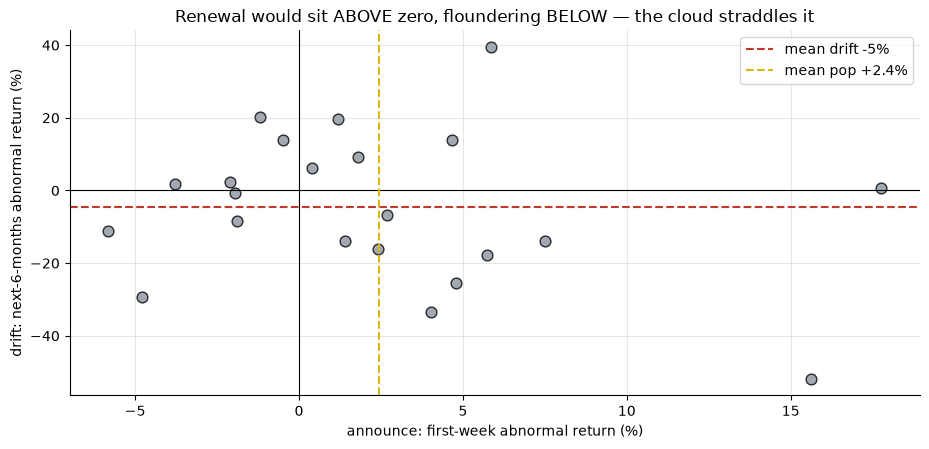

mean pop +2.4%   mean drift -4.6%  (renewal>0, floundering<0)


In [2]:
if HAVE_REAL:
    anns = EV['announce'].values*100; drs = EV['drift'].values*100; labels = EV['ticker'].values
else:
    rng=np.random.default_rng(722)
    anns=rng.normal(R['announce'][0],6,R['n_priced']); drs=rng.normal(R['drift'][0],20,R['n_priced'])
    labels=[f'R{i}' for i in range(R['n_priced'])]
fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.scatter(anns, drs, c=GREY, s=60, edgecolor='k', alpha=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c='k', lw=.8)
ax.axhline(np.mean(drs), c=RED, ls='--', label=f'mean drift {np.mean(drs):+.0f}%')
ax.axvline(np.mean(anns), c=AMBER, ls='--', label=f'mean pop {np.mean(anns):+.1f}%')
ax.set_xlabel('announce: first-week abnormal return (%)')
ax.set_ylabel('drift: next-6-months abnormal return (%)')
ax.set_title('Renewal would sit ABOVE zero, floundering BELOW — the cloud straddles it')
ax.legend(); plt.tight_layout(); plt.show()
print(f'mean pop {np.mean(anns):+.1f}%   mean drift {np.mean(drs):+.1f}%  (renewal>0, floundering<0)')

There's the tell — or the absence of one. If rebrands meant *renewal*, the dots would sit **above** zero (positive drift); if they meant *floundering*, **below**. Instead the mean drift is **-5%** and the cloud straddles the line. The pop leans faintly positive; the drift is a wash.

**The two legs as averages.** Mean abnormal announce-pop and drift, with the win-rate (how often each leg is positive). A coin is 50%.

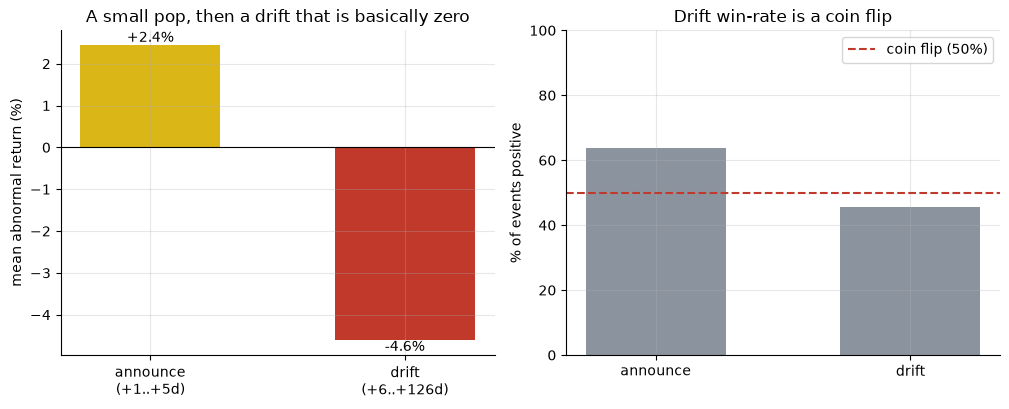

announce +2.4% (win 64%)   drift -4.6% (win 45%)


In [3]:
if HAVE_REAL:
    s = st.summarize(EV, B, placebo=False)
    am, aw = s['announce']['mean']*100, s['announce']['win']*100
    dm, dw = s['drift']['mean']*100, s['drift']['win']*100
else:
    am, aw, dm, dw = R['announce'][0], R['announce'][1], R['drift'][0], R['drift'][1]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.2, 4.2))
a1.bar(['announce\n(+1..+5d)', 'drift\n(+6..+126d)'], [am, dm], color=[AMBER, RED], width=.55)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('mean abnormal return (%)')
a1.set_title('A small pop, then a drift that is basically zero')
for i,v in enumerate([am,dm]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
a2.bar(['announce','drift'], [aw, dw], color=GREY, width=.55)
a2.axhline(50, c=RED, ls='--', label='coin flip (50%)')
a2.set_ylim(0,100); a2.set_ylabel('% of events positive'); a2.set_title('Drift win-rate is a coin flip')
a2.legend(); plt.tight_layout(); plt.show()
print(f'announce {am:+.1f}% (win {aw:.0f}%)   drift {dm:+.1f}% (win {dw:.0f}%)')

The pop is **+2.4%** and positive **64%** of the time; the drift is **-5%** and a **45%** coin-flip. Neither camp's promise — a re-rating up, or a slide down — reliably shows on the survivors.

**Could a handful of random windows look this good?** The honest small-sample test for the *drift* (the actual renewal/floundering claim): draw **22** *random* windows on the same stocks, over and over, and see where the real drift lands against pure luck.

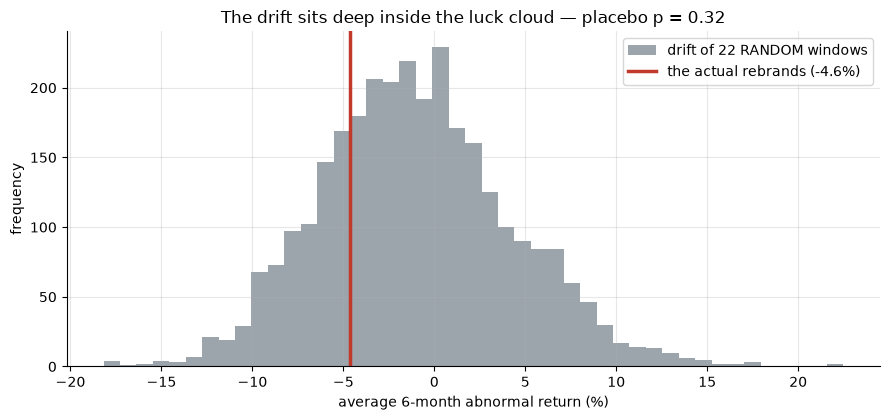

a random 22-window draw matches the drift 32% of the time — not rare at all


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(B, len(EV), leg='drift', observed=EV['drift'].mean(), n_draws=4000)
    obs = pl['obs']*100; pval = pl['p_value']
    tickers=[c for c in B['prices'].columns if c!='SPY']
    exs=[st._excess_log_returns(B['prices'][t], B['prices']['SPY']) for t in tickers]
    exs=[s for s in exs if len(s)>200]; rng=np.random.default_rng(722)
    draws=[]
    for _ in range(3000):
        vals=[]
        for _ in range(len(EV)):
            s=exs[rng.integers(0,len(exs))]; p0=rng.integers(1,len(s)-130); vals.append(np.expm1(s.iloc[p0:p0+120].sum()))
        draws.append(np.mean(vals))
    draws=np.array(draws)*100
else:
    obs=R['drift'][0]; pval=R['drift'][3]; rng=np.random.default_rng(722); draws=rng.normal(0,4.5,3000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label=f'drift of {R["n_priced"]} RANDOM windows')
ax.axvline(obs, c=RED, lw=2.5, label=f'the actual rebrands ({obs:+.1f}%)')
ax.set_xlabel('average 6-month abnormal return (%)'); ax.set_ylabel('frequency')
ax.set_title(f'The drift sits deep inside the luck cloud — placebo p = {pval:.2f}')
ax.legend(); plt.tight_layout(); plt.show()
print(f'a random {R["n_priced"]}-window draw matches the drift {pval*100:.0f}% of the time — not rare at all')

The red line — the real rebrands' drift — sits **squarely inside** the grey luck cloud (placebo *p* ≈ **0.33**). In plain terms: **a couple-dozen random dates would look about this 'special' one-in-three times.** There is no renewal signal and no floundering signal in the drift — just noise.

## 5 · The verdict

- **Signal — Weak.** The renewal/floundering claim lives in the **drift**, and the drift is **-5%** at a *t* of **-1.05** — pure noise (a `NONE`). The only positive is a first-week **+2.4%** pop, but it *fails* the significance bar and **collapses when two news-confounded outliers leave** — a fragile `WEAK`, not a real edge.
- **Tradability — Mirage.** Buy-the-rebrand-and-hold is **-2.2% per event before costs** — the soft negative drift eats the little pop.
- **Renewal or red-flag? — Coin flip.** The drift can't tell them apart. Name-changes drift *down*, logo refreshes drift *up* — which is the firm's pre-existing health leaking through backwards, not a signal you can act on.

## 6 · Could you actually trade it? — the pop the outliers built

Forget the drift and just price the renewal camp's trade: **buy the reveal, hold six months.** And then check the one leg that looked alive — the week-one pop — for how much of it is really just *two* stocks.

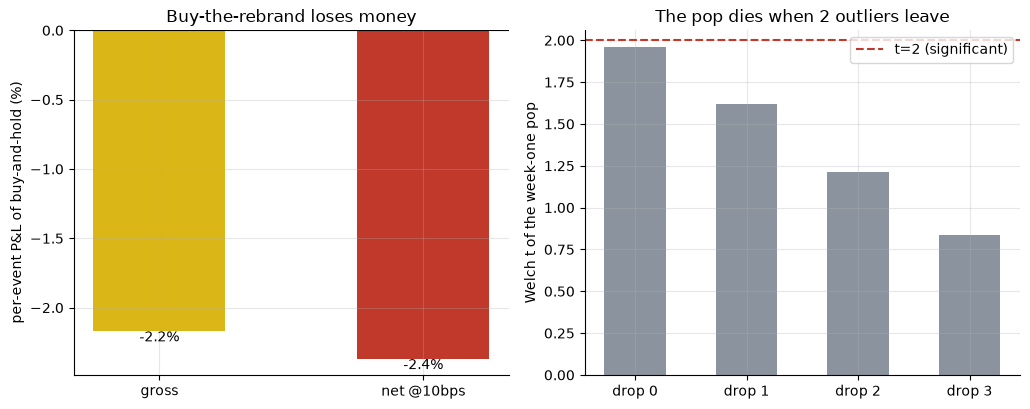

buy-and-hold: -2.2% gross, -2.4% net
pop t as biggest outliers drop: [(0, 1.96), (1, 1.62), (2, 1.21), (3, 0.84)]


In [5]:
if HAVE_REAL:
    c = st.net_of_costs(EV, cost_bps=10.0)
    gh, nh = c['gross_hold']*100, c['net_hold']*100
    a = EV['announce'].values; order=np.argsort(-np.abs(a))
    frag=[]
    for drop in (0,1,2,3):
        keep=np.ones(len(a),bool); keep[order[:drop]]=False
        frag.append((drop, a[keep].mean()*100, st.welch_t(a[keep])))
else:
    gh, nh = R['cost']['gross_hold'], R['cost']['net_hold']
    frag=[(f[0],f[2],f[3]) for f in R['fragile']]
fig, (a1,a2) = plt.subplots(1,2,figsize=(10.4, 4.2))
a1.bar(['gross', 'net @10bps'], [gh, nh], color=[AMBER, RED], width=.5)
a1.axhline(0, c='k', lw=.8); a1.set_ylabel('per-event P&L of buy-and-hold (%)')
a1.set_title('Buy-the-rebrand loses money')
for i,v in enumerate([gh,nh]): a1.annotate(f'{v:+.1f}%',(i,v),ha='center',va='top')
dd=[f'drop {f[0]}' for f in frag]; tt=[f[2] for f in frag]
a2.bar(dd, tt, color=GREY, width=.55); a2.axhline(2, ls='--', c=RED, label='t=2 (significant)')
a2.set_ylabel('Welch t of the week-one pop'); a2.set_title('The pop dies when 2 outliers leave')
a2.legend(); plt.tight_layout(); plt.show()
print(f'buy-and-hold: {gh:+.1f}% gross, {nh:+.1f}% net'); print('pop t as biggest outliers drop:', [(d,round(t,2)) for d,_,t in frag])

The hold book is **-2.2% gross** / **-2.4% net** — a money-loser, because the six-month drift is soft-negative. And the one leg that flickered — the week-one pop — has a *t* of **1.96** that falls to **1.21** the moment you remove just **two** stocks (BlackBerry, whose pop was really its BB10 phone launch, and GM, mid-EV-re-rating). Take away two headlines that had nothing to do with the logo, and the 'rebrand pop' is a coin flip. There's no machine here.

## 7 · Going further 🚪

- **The theme-chasing cousin.** [Study 389 — Name-Change-Effect](../389-name-change-effect/) tests the `.com`/`Blockchain`/`AI` renames — the 'pop then dump' variant, same family (a label, not a fundamental), same verdict.
- **The anecdote trap.** [Study 343 — Data-Mining-Roulette](../343-data-mining-roulette/) shows how a few loud cases (here: two confounded outliers) manufacture a 'law.'
- **Add the corpses.** Our survivor tape is biased *against* the floundering story; get delisted/private data (Twitter→X, WW, Bed Bath & Beyond) and the drift might turn negative — but that's a bankruptcy, not a tradable 'signal,' and you couldn't have shorted a private company anyway.

*Think the rebrand signal is real and harvestable? Capture the events, draw the same number of random windows, and show the drift landing **outside** the cloud — reliably one sign, surviving the removal of your two biggest names — then we'll talk.*